In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SR = 22050
WINDOW_SAMPLES = 11025  # 500ms at 22050 Hz

# Load prepared dataset
X_audio = np.load(PROCESSED_DIR / "windows_audio.npy")
metadata_df = pd.read_parquet(PROCESSED_DIR / "windows_metadata.parquet")

print(f"Audio windows: {X_audio.shape}, dtype: {X_audio.dtype}")
print(f"Metadata: {metadata_df.shape}")
print(f"\nSplit sizes:")
print(metadata_df["split"].value_counts())

Audio windows: (19983, 11025), dtype: float32
Metadata: (19983, 5)

Split sizes:
split
train    12964
val       3513
test      3506
Name: count, dtype: int64


In [2]:
def extract_features(audio: np.ndarray, sr: int = SR) -> np.ndarray:
    """
    Extract classical MIR features from a single audio window.
    Returns a 62-dim feature vector.
    """
    # Chroma — 12 pitch classes (mean + std across frames)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_fft=2048, hop_length=512)

    # MFCC — 13 coefficients (timbre)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13, n_fft=2048, hop_length=512)

    # Spectral shape descriptors
    spec_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=2048, hop_length=512)
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=2048, hop_length=512)
    spec_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, n_fft=2048, hop_length=512)
    spec_flatness = librosa.feature.spectral_flatness(y=audio, n_fft=2048, hop_length=512)

    # Time-domain descriptors
    zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=512)
    rms = librosa.feature.rms(y=audio, hop_length=512)

    # Aggregate each per-frame feature to (mean, std)
    def agg(feat: np.ndarray) -> np.ndarray:
        return np.concatenate([feat.mean(axis=1), feat.std(axis=1)])

    return np.concatenate([
        agg(chroma),        # 24
        agg(mfcc),          # 26
        agg(spec_centroid), # 2
        agg(spec_bandwidth),# 2
        agg(spec_rolloff),  # 2
        agg(spec_flatness), # 2
        agg(zcr),           # 2
        agg(rms),           # 2
    ]).astype(np.float32)


# Test on window 0
test_feats = extract_features(X_audio[0])
print(f"Feature vector shape: {test_feats.shape}")
print(f"Feature vector dtype: {test_feats.dtype}")
print(f"First 12 (chroma means): {test_feats[:12].round(3)}")
print(f"Class label of window 0: {metadata_df.iloc[0]['class_name']}")

Feature vector shape: (62,)
Feature vector dtype: float32
First 12 (chroma means): [0.078 0.166 0.72  0.932 0.627 0.676 0.283 0.108 0.09  0.099 0.154 0.121]
Class label of window 0: maj:D#


In [3]:
print(f"Extracting features for {len(X_audio)} windows...")

X_features = np.zeros((len(X_audio), 62), dtype=np.float32)
for i in tqdm(range(len(X_audio)), desc="Features"):
    X_features[i] = extract_features(X_audio[i])

# Any NaN or inf sneaked in?
n_nan = int(np.isnan(X_features).sum())
n_inf = int(np.isinf(X_features).sum())
print(f"\nX_features shape: {X_features.shape}")
print(f"NaN values: {n_nan}")
print(f"Inf values: {n_inf}")
print(f"Value range: [{X_features.min():.3f}, {X_features.max():.3f}]")

# Save so we don't recompute
np.save(PROCESSED_DIR / "windows_features_classical.npy", X_features)
print(f"\nSaved to {PROCESSED_DIR / 'windows_features_classical.npy'}")

Extracting features for 19983 windows...


Features:  33%|███▎      | 6551/19983 [01:11<02:23, 93.34it/s]c:\Users\Constantine\Code\ml-project\.venv\Lib\site-packages\librosa\core\pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Features: 100%|██████████| 19983/19983 [03:37<00:00, 91.99it/s]


X_features shape: (19983, 62)
NaN values: 0
Inf values: 0
Value range: [-785.766, 6690.464]

Saved to c:\Users\Constantine\Code\ml-project\data\processed\windows_features_classical.npy


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split features + labels using the split column we saved earlier
train_mask = metadata_df["split"] == "train"
val_mask = metadata_df["split"] == "val"
test_mask = metadata_df["split"] == "test"

X_train = X_features[train_mask]
y_train = metadata_df.loc[train_mask, "class_id"].to_numpy()

X_val = X_features[val_mask]
y_val = metadata_df.loc[val_mask, "class_id"].to_numpy()

X_test = X_features[test_mask]
y_test = metadata_df.loc[test_mask, "class_id"].to_numpy()

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

# Baseline for "random guessing" — what accuracy does always-predict-most-common get?
majority_class = int(pd.Series(y_train).mode().iloc[0])
majority_acc = float((y_val == majority_class).mean())
print(f"\nMajority-class baseline on val: {majority_acc:.3f} "
      f"(always predict {majority_class})")

Train: X=(12964, 62), y=(12964,)
Val:   X=(3513, 62), y=(3513,)
Test:  X=(3506, 62), y=(3506,)

Majority-class baseline on val: 0.081 (always predict 13)


In [5]:
# Random Forest — reasonable defaults, class_weight balanced for imbalance
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,        # use all CPU cores
    random_state=42,
    verbose=1,
)

print("Training Random Forest...")
rf.fit(X_train, y_train)

# Predict on val
y_val_pred = rf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"\n{'='*50}")
print(f"Random Forest — Validation Accuracy: {val_acc:.3f}")
print(f"{'='*50}")

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    4.9s



Random Forest — Validation Accuracy: 0.573


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    5.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


In [6]:
id_to_name = dict(zip(metadata_df["class_id"], metadata_df["class_name"]))
target_names = [id_to_name[i] for i in sorted(id_to_name.keys())]

print("Classification report on validation set:\n")
print(classification_report(
    y_val, y_val_pred,
    target_names=target_names,
    digits=3,
    zero_division=0,
))

Classification report on validation set:

              precision    recall  f1-score   support

      note:C      0.667     1.000     0.800        22
     note:C#      0.706     0.947     0.809        38
      note:D      0.976     0.953     0.965        43
     note:D#      0.750     1.000     0.857        42
      note:E      0.944     0.971     0.958        35
      note:F      0.903     0.875     0.889        32
     note:F#      0.907     0.951     0.929        41
      note:G      0.981     0.981     0.981        52
     note:G#      0.831     0.915     0.871        59
      note:A      0.955     0.913     0.933        23
     note:A#      0.774     1.000     0.872        41
      note:B      0.833     0.926     0.877        27
       maj:C      0.438     0.464     0.451       222
      maj:C#      0.810     0.661     0.728       283
       maj:D      0.461     0.281     0.349       167
      maj:D#      0.629     0.753     0.685       227
       maj:E      0.578     0.750     0

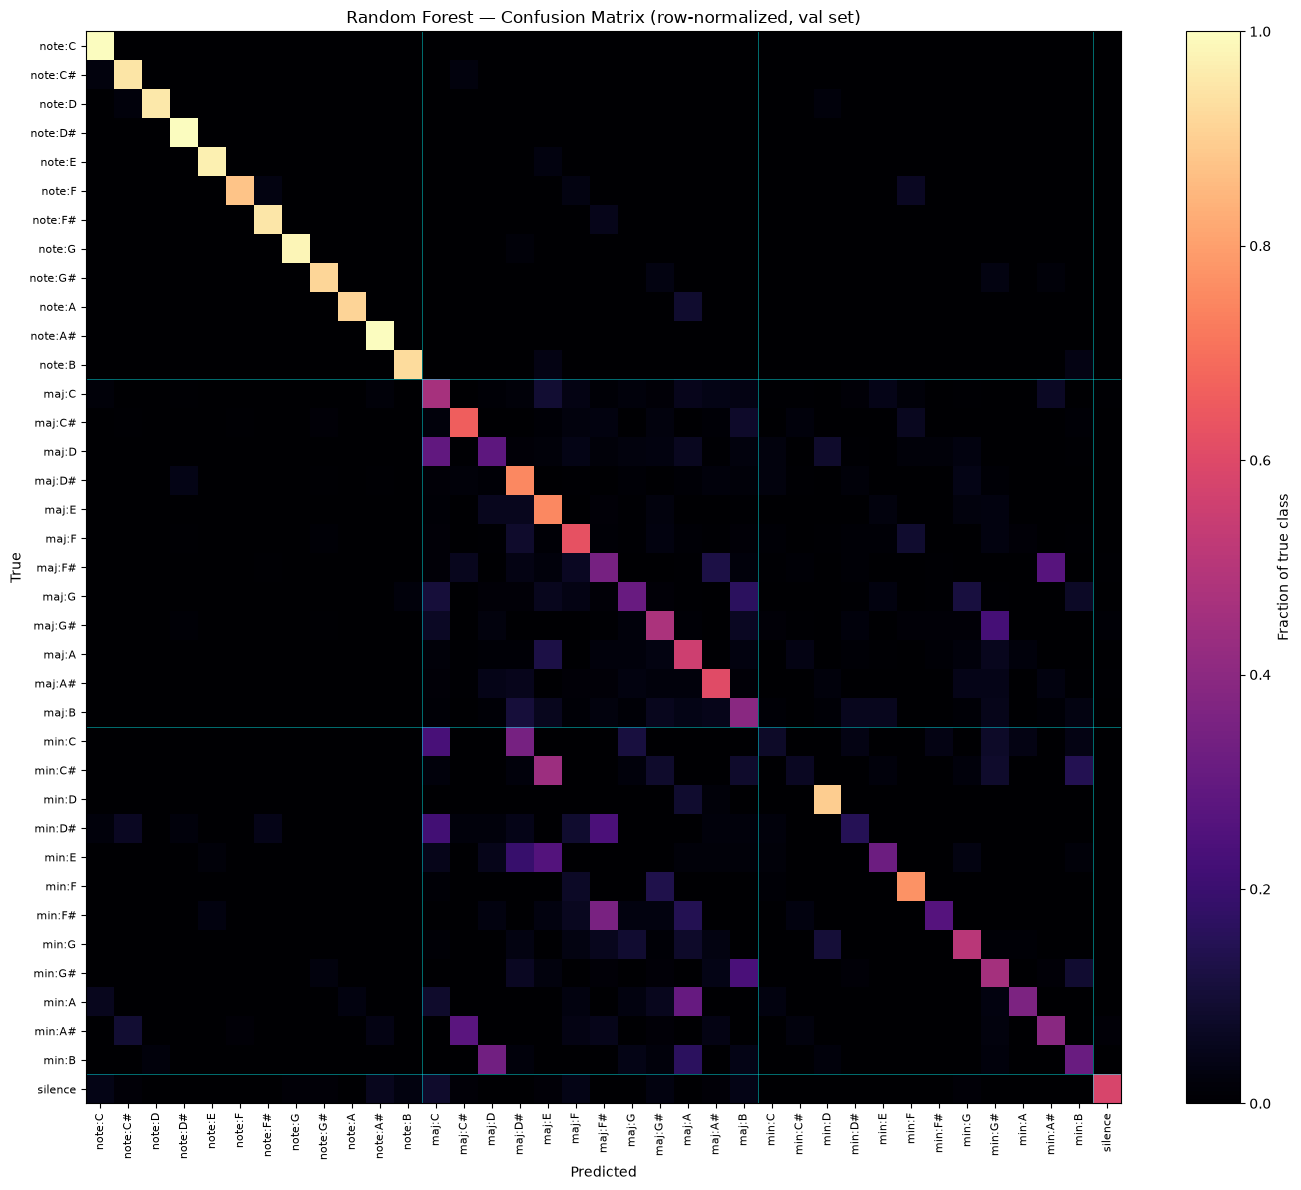

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred, labels=list(range(37)))

# Normalize by row (percent of each true class going to each predicted class)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, cmap="magma", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(37))
ax.set_yticks(range(37))
ax.set_xticklabels(target_names, rotation=90, fontsize=8)
ax.set_yticklabels(target_names, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Random Forest — Confusion Matrix (row-normalized, val set)")

# Group boundaries: 0-11 notes, 12-23 majors, 24-35 minors, 36 silence
for boundary in [11.5, 23.5, 35.5]:
    ax.axhline(boundary, color="cyan", linewidth=0.5, alpha=0.6)
    ax.axvline(boundary, color="cyan", linewidth=0.5, alpha=0.6)

fig.colorbar(im, ax=ax, label="Fraction of true class")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "report" / "rf_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()